In [44]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

dataset =load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [45]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]

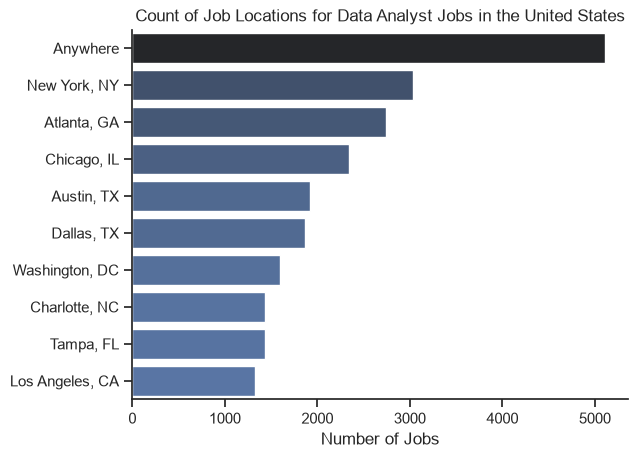

In [ ]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Count of Job Locations for Data Analyst Jobs in the United States')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show() 

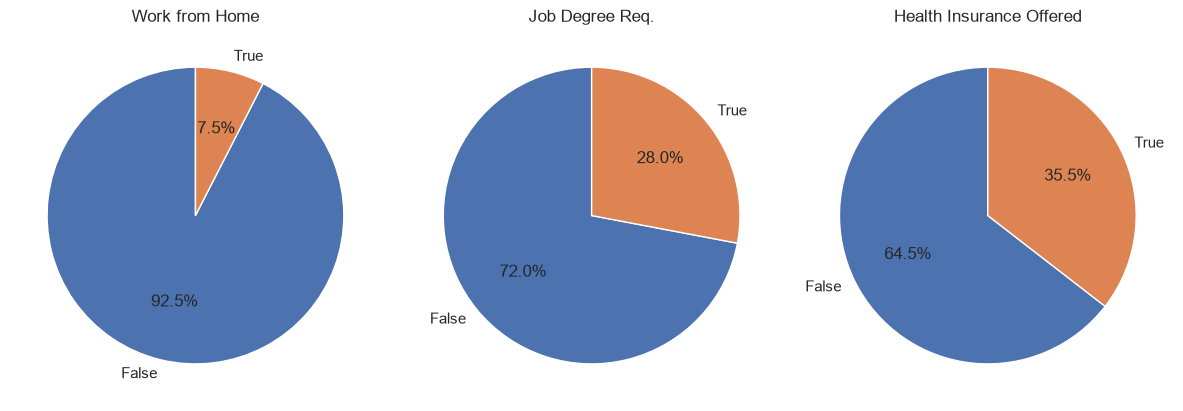

In [47]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))

dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

for i, (column, title) in enumerate(dict_column.items()):
    counts = df_DA_US[column].value_counts().reindex([False, True], fill_value=0)

    ax[i].pie(
        counts,
        startangle=90,
        autopct='%1.1f%%',
        labels=['False', 'True']
    )
    ax[i].set_title(title)

plt.tight_layout()
plt.show()



In [50]:
for column in dict_column:
    print(column)
    print(df_DA_US[column].value_counts())
    print()

job_work_from_home
job_work_from_home
False    62710
True      5106
Name: count, dtype: int64

job_no_degree_mention
job_no_degree_mention
False    48840
True     18976
Name: count, dtype: int64

job_health_insurance
job_health_insurance
False    43755
True     24061
Name: count, dtype: int64



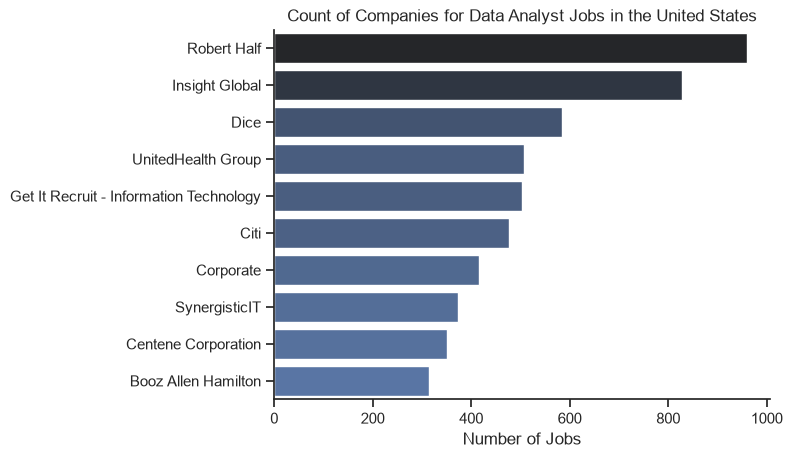

In [52]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Count of Companies for Data Analyst Jobs in the United States')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()